# 11 — Long-Training Clinical Generalization

Notebook 10 trained the selected combined public-data augmentation recipe longer on public data only. This notebook evaluates that trained public-data model on the same PSD-derived clinical subset used in Notebook 08.

This notebook is the third phase of the 09–11 generalization-optimization workflow:

1. **Notebook 09** screened combined public augmentation recipes using public validation performance.
2. **Notebook 10** retrained the selected Notebook 09 recipe longer on public data only.
3. **Notebook 11** evaluates the Notebook 10 model on clinical PSD-derived data and compares it to Notebook 08.

The clinical data are used only for evaluation in this notebook. No clinical samples are used for training, validation, tuning, or model selection.

In [1]:
# 11.01 — Imports

from __future__ import annotations

import json
import os
import platform
import sys
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display


In [2]:
# 11.02 — Project root and source path setup

def find_project_root(start: Path | None = None) -> Path:
    """Find the repository root by walking upward to the .git directory."""
    current = Path.cwd() if start is None else Path(start).resolve()

    for candidate in [current, *current.parents]:
        if (candidate / ".git").exists():
            return candidate

    raise FileNotFoundError("Could not find project root containing .git.")


PROJECT_ROOT = find_project_root()
SRC_DIR = PROJECT_ROOT / "src"

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

os.chdir(PROJECT_ROOT)

print(f"Project root: {PROJECT_ROOT.name}")
print(f"Source directory available: {SRC_DIR.exists()}")
print(f"Python executable: {sys.executable}")
print(f"Python version: {platform.python_version()}")


Project root: Automated-Glaucoma-Screening-Using-AI-Enhanced-Ophthalmoscopy
Source directory available: True
Python executable: <HOME>/.conda/envs/glaucoma-capstone/bin/python
Python version: 3.11.15


In [3]:
# 11.03 — Paths and output directories

REPORTS_DIR = PROJECT_ROOT / "reports"
TRAINING_REPORT_DIR = REPORTS_DIR / "training"
DATA_AUDIT_REPORT_DIR = REPORTS_DIR / "data_audit"

PRIVATE_CLINICAL_DIR = PROJECT_ROOT / "data/interim/private_clinical_generalization"
PRIVATE_NOTEBOOK_10_CHECKPOINT_DIR = PROJECT_ROOT / "data/interim/private_model_checkpoints/notebook_10"

TRAINING_REPORT_DIR.mkdir(parents=True, exist_ok=True)
DATA_AUDIT_REPORT_DIR.mkdir(parents=True, exist_ok=True)
PRIVATE_CLINICAL_DIR.mkdir(parents=True, exist_ok=True)

NOTEBOOK_08_IMAGE_WEIGHTED_PATH = TRAINING_REPORT_DIR / "clinical_generalization_evaluation_summary.csv"
NOTEBOOK_08_PATIENT_WEIGHTED_PATH = TRAINING_REPORT_DIR / "clinical_generalization_patient_weighted_summary.csv"
NOTEBOOK_08_DATASET_SUMMARY_PATH = DATA_AUDIT_REPORT_DIR / "clinical_generalization_dataset_summary.csv"

NOTEBOOK_10_SUMMARY_PATH = TRAINING_REPORT_DIR / "long_training_selected_public_summary.csv"
NOTEBOOK_10_TEST_SUMMARY_PATH = TRAINING_REPORT_DIR / "long_training_selected_public_test_summary.csv"
NOTEBOOK_10_METADATA_PATH = TRAINING_REPORT_DIR / "long_training_selected_public_metadata.csv"

PRIVATE_CLINICAL_MANIFEST_PATH = (
    PRIVATE_CLINICAL_DIR / "clinical_psd_derived_mask_manifest_private.csv"
)
PRIVATE_NOTEBOOK_10_BEST_CHECKPOINT_PATH = (
    PRIVATE_NOTEBOOK_10_CHECKPOINT_DIR / "long_training_selected_public_best_state_private.pt"
)

PRIVATE_IMAGE_LEVEL_METRICS_PATH = (
    PRIVATE_CLINICAL_DIR / "long_training_clinical_generalization_image_level_metrics_private.csv"
)

DATASET_SUMMARY_PATH = DATA_AUDIT_REPORT_DIR / "long_training_clinical_generalization_dataset_summary.csv"
METADATA_PATH = TRAINING_REPORT_DIR / "long_training_clinical_generalization_metadata.csv"
IMAGE_WEIGHTED_SUMMARY_PATH = TRAINING_REPORT_DIR / "long_training_clinical_generalization_evaluation_summary.csv"
PATIENT_WEIGHTED_SUMMARY_PATH = TRAINING_REPORT_DIR / "long_training_clinical_generalization_patient_weighted_summary.csv"
COMPARISON_PATH = TRAINING_REPORT_DIR / "long_training_clinical_generalization_comparison_to_notebook_08.csv"

paths = pd.DataFrame(
    [
        {"artifact": "Notebook 08 image-weighted clinical summary", "path": NOTEBOOK_08_IMAGE_WEIGHTED_PATH, "exists": NOTEBOOK_08_IMAGE_WEIGHTED_PATH.exists(), "required": True, "commit": False},
        {"artifact": "Notebook 08 patient-weighted clinical summary", "path": NOTEBOOK_08_PATIENT_WEIGHTED_PATH, "exists": NOTEBOOK_08_PATIENT_WEIGHTED_PATH.exists(), "required": True, "commit": False},
        {"artifact": "Notebook 08 public clinical dataset summary", "path": NOTEBOOK_08_DATASET_SUMMARY_PATH, "exists": NOTEBOOK_08_DATASET_SUMMARY_PATH.exists(), "required": True, "commit": False},
        {"artifact": "Notebook 10 public summary", "path": NOTEBOOK_10_SUMMARY_PATH, "exists": NOTEBOOK_10_SUMMARY_PATH.exists(), "required": True, "commit": False},
        {"artifact": "Notebook 10 public test summary", "path": NOTEBOOK_10_TEST_SUMMARY_PATH, "exists": NOTEBOOK_10_TEST_SUMMARY_PATH.exists(), "required": True, "commit": False},
        {"artifact": "Notebook 10 public metadata", "path": NOTEBOOK_10_METADATA_PATH, "exists": NOTEBOOK_10_METADATA_PATH.exists(), "required": True, "commit": False},
        {"artifact": "private clinical manifest from Notebook 08", "path": PRIVATE_CLINICAL_MANIFEST_PATH, "exists": PRIVATE_CLINICAL_MANIFEST_PATH.exists(), "required": True, "commit": False},
        {"artifact": "private Notebook 10 best checkpoint", "path": PRIVATE_NOTEBOOK_10_BEST_CHECKPOINT_PATH, "exists": PRIVATE_NOTEBOOK_10_BEST_CHECKPOINT_PATH.exists(), "required": True, "commit": False},
        {"artifact": "private Notebook 11 image-level metrics", "path": PRIVATE_IMAGE_LEVEL_METRICS_PATH, "exists": PRIVATE_IMAGE_LEVEL_METRICS_PATH.exists(), "required": False, "commit": False},
        {"artifact": "Notebook 11 dataset summary", "path": DATASET_SUMMARY_PATH, "exists": DATASET_SUMMARY_PATH.exists(), "required": False, "commit": True},
        {"artifact": "Notebook 11 metadata", "path": METADATA_PATH, "exists": METADATA_PATH.exists(), "required": False, "commit": True},
        {"artifact": "Notebook 11 image-weighted summary", "path": IMAGE_WEIGHTED_SUMMARY_PATH, "exists": IMAGE_WEIGHTED_SUMMARY_PATH.exists(), "required": False, "commit": True},
        {"artifact": "Notebook 11 patient-weighted summary", "path": PATIENT_WEIGHTED_SUMMARY_PATH, "exists": PATIENT_WEIGHTED_SUMMARY_PATH.exists(), "required": False, "commit": True},
        {"artifact": "Notebook 11 comparison summary", "path": COMPARISON_PATH, "exists": COMPARISON_PATH.exists(), "required": False, "commit": True},
    ]
)

display(paths.assign(path=paths["path"].map(lambda path: str(Path(path).relative_to(PROJECT_ROOT)))))

missing_required = paths.loc[paths["required"] & ~paths["exists"], "artifact"].tolist()

if missing_required:
    raise FileNotFoundError(
        "Missing required Notebook 11 inputs. Do not rebuild silently. "
        f"Missing: {missing_required}"
    )


,artifact,path,exists,required,commit
0,Notebook 08 image-weighted clinical summary,reports/training/clinical_generalization_evalu...,True,True,False
1,Notebook 08 patient-weighted clinical summary,reports/training/clinical_generalization_patie...,True,True,False
2,Notebook 08 public clinical dataset summary,reports/data_audit/clinical_generalization_dat...,True,True,False
3,Notebook 10 public summary,reports/training/long_training_selected_public...,True,True,False
4,Notebook 10 public test summary,reports/training/long_training_selected_public...,True,True,False
5,Notebook 10 public metadata,reports/training/long_training_selected_public...,True,True,False
6,private clinical manifest from Notebook 08,data/interim/private_clinical_generalization/c...,True,True,False
7,private Notebook 10 best checkpoint,data/interim/private_model_checkpoints/noteboo...,True,True,False
8,private Notebook 11 image-level metrics,data/interim/private_clinical_generalization/l...,False,False,False
9,Notebook 11 dataset summary,reports/data_audit/long_training_clinical_gene...,True,False,True


In [4]:
# 11.04 — Core project module import check

from glaucoma_segmentation.clinical import (
    ClinicalDerivedMaskDataset,
    evaluate_model_on_clinical_loader,
    summarize_image_level_clinical_metrics,
    summarize_patient_weighted_clinical_metrics,
)
from glaucoma_segmentation.data.dataloaders import make_segmentation_dataloader
from glaucoma_segmentation.nets.model_factory import build_model
from glaucoma_segmentation.utils.device import device_summary_dict, get_device
from glaucoma_segmentation.utils.seed import seed_everything

print("Core project imports: OK")


<HOME>/.conda/envs/glaucoma-capstone/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Core project imports: OK


In [5]:
# 11.05 — Clinical evaluation configuration

SEED = 42
IMAGE_SIZE = (256, 256)
BATCH_SIZE = 8
NUM_CLASSES = 3
PIN_MEMORY = torch.cuda.is_available()

cpu_count = os.cpu_count() or 2
NUM_WORKERS = min(4, max(1, cpu_count - 1))

FORCE_RERUN = False

seed_config = seed_everything(SEED, deterministic=False)
DEVICE = get_device()
DEVICE_INFO = device_summary_dict(DEVICE)

config = {
    "seed": SEED,
    "image_size": IMAGE_SIZE,
    "batch_size": BATCH_SIZE,
    "num_classes": NUM_CLASSES,
    "num_workers": NUM_WORKERS,
    "pin_memory": PIN_MEMORY,
    "device": str(DEVICE),
    "seed_config": seed_config,
    "clinical_data_usage": "evaluation_only",
    "private_checkpoint_required": True,
}

display(pd.DataFrame([config | DEVICE_INFO]))


,seed,image_size,batch_size,num_classes,num_workers,pin_memory,device,seed_config,clinical_data_usage,private_checkpoint_required,device_type,name,cuda_available,cuda_device_count,mps_available
0,42,"(256, 256)",8,3,4,True,cuda,"SeedConfig(seed=42, deterministic=False, cudnn...",evaluation_only,True,cuda,NVIDIA RTX A6000,True,1,False


## Clinical evaluation rule

Notebook 11 does not retrain or tune the model. It loads the best private checkpoint saved by Notebook 10 and evaluates that public-data-trained model on the same clinical PSD-derived mask-ready subset used in Notebook 08.

If the private Notebook 10 checkpoint is missing, this notebook should stop. It should not silently rebuild or retrain Notebook 10.

In [6]:
# 11.06 — Load Notebook 10 public metadata and private checkpoint

notebook_10_summary = pd.read_csv(NOTEBOOK_10_SUMMARY_PATH)
notebook_10_test_summary = pd.read_csv(NOTEBOOK_10_TEST_SUMMARY_PATH)
notebook_10_metadata = pd.read_csv(NOTEBOOK_10_METADATA_PATH)

if len(notebook_10_summary) != 1:
    raise RuntimeError(f"Expected one Notebook 10 summary row, found {len(notebook_10_summary)}.")
if len(notebook_10_test_summary) != 1:
    raise RuntimeError(f"Expected one Notebook 10 test summary row, found {len(notebook_10_test_summary)}.")

notebook_10_row = notebook_10_summary.iloc[0].to_dict()
notebook_10_test_row = notebook_10_test_summary.iloc[0].to_dict()

checkpoint = torch.load(PRIVATE_NOTEBOOK_10_BEST_CHECKPOINT_PATH, map_location="cpu")

model_name = str(checkpoint.get("model_name", notebook_10_row["model_name"]))
encoder_name = str(checkpoint.get("encoder_name", notebook_10_row["encoder_name"]))
encoder_weights = checkpoint.get("encoder_weights", None)
strategy_name = str(checkpoint.get("strategy_name", notebook_10_row["strategy_name"]))
component_strategies = str(checkpoint.get("component_strategies", notebook_10_row["component_strategies"]))
checkpoint_epoch = int(checkpoint.get("epoch", notebook_10_row["best_epoch_by_val_mean_foreground_dice"]))

expected_pairs = {
    "model_name": (model_name, str(notebook_10_row["model_name"])),
    "encoder_name": (encoder_name, str(notebook_10_row["encoder_name"])),
    "strategy_name": (strategy_name, str(notebook_10_row["strategy_name"])),
    "component_strategies": (component_strategies, str(notebook_10_row["component_strategies"])),
}

for field_name, (checkpoint_value, summary_value) in expected_pairs.items():
    if checkpoint_value != summary_value:
        raise RuntimeError(
            f"Checkpoint and Notebook 10 summary disagree for {field_name}: "
            f"checkpoint={checkpoint_value!r}; summary={summary_value!r}"
        )

checkpoint_summary = {
    "checkpoint_type": checkpoint.get("checkpoint_type"),
    "run_name": checkpoint.get("run_name"),
    "epoch": checkpoint_epoch,
    "model_name": model_name,
    "encoder_name": encoder_name,
    "encoder_weights": encoder_weights,
    "strategy_name": strategy_name,
    "component_strategies": component_strategies,
    "num_classes": checkpoint.get("num_classes", NUM_CLASSES),
    "clinical_data_used_in_training": checkpoint.get("clinical_data_used", None),
    "private_checkpoint_loaded": True,
}

display(pd.DataFrame([checkpoint_summary]))


/tmp/ipykernel_902196/3470986934.py:15: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(PRIVATE_NOTEBOOK_10_BEST_CHECKPOINT_PATH, map_location="cpu")


,checkpoint_type,run_name,epoch,model_name,encoder_name,encoder_weights,strategy_name,component_strategies,num_classes,clinical_data_used_in_training,private_checkpoint_loaded
0,best_validation,long_unetplusplus_resnet18_combo_affine_vignet...,24,unetplusplus,resnet18,None,combo_affine_vignette_blur,small_affine;vignette_illumination;defocus_blur,3,False,True


In [7]:
# 11.07 — Build and load the Notebook 10 model

model = build_model(
    model_name=model_name,
    in_channels=3,
    classes=NUM_CLASSES,
    encoder_name=encoder_name,
    encoder_weights=encoder_weights,
)

model.load_state_dict(checkpoint["model_state_dict"])
model.to(DEVICE)
model.eval()

model_summary = {
    "model_name": model_name,
    "encoder_name": encoder_name,
    "encoder_weights": encoder_weights,
    "strategy_name": strategy_name,
    "component_strategies": component_strategies,
    "checkpoint_epoch": checkpoint_epoch,
    "device": str(DEVICE),
}

display(pd.DataFrame([model_summary]))
print("Notebook 10 model loaded: OK")


,model_name,encoder_name,encoder_weights,strategy_name,component_strategies,checkpoint_epoch,device
0,unetplusplus,resnet18,None,combo_affine_vignette_blur,small_affine;vignette_illumination;defocus_blur,24,cuda


Notebook 10 model loaded: OK


In [8]:
# 11.08 — Build the same clinical PSD-derived evaluation dataset used in Notebook 08

clinical_manifest = pd.read_csv(PRIVATE_CLINICAL_MANIFEST_PATH)

clinical_dataset = ClinicalDerivedMaskDataset(
    clinical_manifest,
    project_root=PROJECT_ROOT,
    image_size=IMAGE_SIZE,
    require_mask_ready=True,
    validate_paths=True,
)

clinical_loader = make_segmentation_dataloader(
    clinical_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    drop_last=False,
)

clinical_frame = clinical_dataset.frame.copy()

clinical_rows = len(clinical_dataset)
clinical_patient_groups = clinical_frame["patient_hash"].nunique()
clinical_eye_counts = clinical_frame["eye"].astype(str).str.upper().value_counts().to_dict()

dataset_summary = pd.DataFrame(
    [
        {
            "dataset_label": "clinical_psd_derived_mask_ready",
            "evaluation_notebook": "11_long_training_clinical_generalization",
            "comparison_baseline_notebook": "08_clinical_data_generalization",
            "clinical_data_usage": "evaluation_only",
            "model_source": "Notebook 10 private best checkpoint",
            "clinical_rows": clinical_rows,
            "clinical_patient_groups": clinical_patient_groups,
            "clinical_eye_od_rows": int(clinical_eye_counts.get("OD", 0)),
            "clinical_eye_os_rows": int(clinical_eye_counts.get("OS", 0)),
            "clinical_eye_unknown_rows": int(clinical_eye_counts.get("UNKNOWN", clinical_eye_counts.get("unknown", 0))),
            "image_size": str(IMAGE_SIZE),
            "contains_raw_paths": False,
            "contains_sample_hashes": False,
            "contains_patient_hashes": False,
            "private_image_level_metrics_committed": False,
        }
    ]
)

dataset_summary.to_csv(DATASET_SUMMARY_PATH, index=False)

display(dataset_summary)
print(f"Clinical loader batches: {len(clinical_loader)}")
print(f"Saved public dataset summary: {DATASET_SUMMARY_PATH.relative_to(PROJECT_ROOT)}")

if clinical_rows != 59:
    raise RuntimeError(f"Expected 59 clinical mask-ready rows from Notebook 08, found {clinical_rows}.")
if clinical_patient_groups != 20:
    raise RuntimeError(
        f"Expected 20 clinical patient/encounter groups from Notebook 08, found {clinical_patient_groups}."
    )


<HOME>/.conda/envs/glaucoma-capstone/lib/python3.11/site-packages/torch/utils/data/dataloader.py:557: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warning_msg(


,dataset_label,evaluation_notebook,comparison_baseline_notebook,clinical_data_usage,model_source,clinical_rows,clinical_patient_groups,clinical_eye_od_rows,clinical_eye_os_rows,clinical_eye_unknown_rows,image_size,contains_raw_paths,contains_sample_hashes,contains_patient_hashes,private_image_level_metrics_committed
0,clinical_psd_derived_mask_ready,11_long_training_clinical_generalization,08_clinical_data_generalization,evaluation_only,Notebook 10 private best checkpoint,59,20,21,13,25,"(256, 256)",False,False,False,False


Clinical loader batches: 8
Saved public dataset summary: reports/data_audit/long_training_clinical_generalization_dataset_summary.csv


In [9]:
# 11.09 — Evaluate Notebook 10 model on clinical PSD-derived data

from glaucoma_segmentation.training.train_loop import model_forward

if (
    IMAGE_WEIGHTED_SUMMARY_PATH.exists()
    and PATIENT_WEIGHTED_SUMMARY_PATH.exists()
    and PRIVATE_IMAGE_LEVEL_METRICS_PATH.exists()
    and not FORCE_RERUN
):
    print("Notebook 11 clinical evaluation outputs already exist. Skipping evaluation because FORCE_RERUN=False.")
    image_weighted_summary = pd.read_csv(IMAGE_WEIGHTED_SUMMARY_PATH)
    patient_weighted_summary = pd.read_csv(PATIENT_WEIGHTED_SUMMARY_PATH)
    image_level_metrics = pd.read_csv(PRIVATE_IMAGE_LEVEL_METRICS_PATH)
else:
    if FORCE_RERUN:
        for output_path in [
            PRIVATE_IMAGE_LEVEL_METRICS_PATH,
            IMAGE_WEIGHTED_SUMMARY_PATH,
            PATIENT_WEIGHTED_SUMMARY_PATH,
            METADATA_PATH,
            COMPARISON_PATH,
        ]:
            if output_path.exists():
                output_path.unlink()
                print(f"Removed existing output: {output_path.relative_to(PROJECT_ROOT)}")

    image_level_metrics = evaluate_model_on_clinical_loader(
        model,
        clinical_loader,
        device=DEVICE,
        model_forward_fn=model_forward,
    )

    if not isinstance(image_level_metrics, pd.DataFrame):
        image_level_metrics = pd.DataFrame(image_level_metrics)

    if image_level_metrics.empty:
        raise ValueError("Clinical evaluation produced zero image-level metric rows.")

    PRIVATE_IMAGE_LEVEL_METRICS_PATH.parent.mkdir(parents=True, exist_ok=True)
    image_level_metrics.to_csv(PRIVATE_IMAGE_LEVEL_METRICS_PATH, index=False)

    image_weighted_summary = summarize_image_level_clinical_metrics(image_level_metrics)
    patient_weighted_summary = summarize_patient_weighted_clinical_metrics(image_level_metrics)

    for frame in [image_weighted_summary, patient_weighted_summary]:
        frame.insert(0, "run_name", str(notebook_10_row["run_name"]))
        frame.insert(1, "model_name", model_name)
        frame.insert(2, "encoder_name", encoder_name)
        frame.insert(3, "strategy_name", strategy_name)
        frame.insert(4, "component_strategies", component_strategies)
        frame.insert(5, "checkpoint_epoch", checkpoint_epoch)
        frame.insert(6, "source_notebook", "10_long_training_selected_public_model")
        frame.insert(7, "clinical_data_usage", "evaluation_only")
        frame["contains_private_paths"] = False
        frame["contains_sample_hashes"] = False
        frame["contains_patient_hashes"] = False
        frame["private_image_level_metrics_committed"] = False

    image_weighted_summary.to_csv(IMAGE_WEIGHTED_SUMMARY_PATH, index=False)
    patient_weighted_summary.to_csv(PATIENT_WEIGHTED_SUMMARY_PATH, index=False)

display(image_weighted_summary)
display(patient_weighted_summary)

print(f"Private image-level metrics saved: {PRIVATE_IMAGE_LEVEL_METRICS_PATH.relative_to(PROJECT_ROOT)}")
print(f"Public image-weighted summary saved: {IMAGE_WEIGHTED_SUMMARY_PATH.relative_to(PROJECT_ROOT)}")
print(f"Public patient-weighted summary saved: {PATIENT_WEIGHTED_SUMMARY_PATH.relative_to(PROJECT_ROOT)}")

<HOME>/.conda/envs/glaucoma-capstone/lib/python3.11/site-packages/torch/utils/data/dataloader.py:557: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warning_msg(


,run_name,model_name,encoder_name,strategy_name,component_strategies,checkpoint_epoch,source_notebook,clinical_data_usage,clinical_rows,clinical_patient_groups,...,image_weighted_mean_foreground_dice_max,image_weighted_cdr_abs_error_mean,image_weighted_cdr_abs_error_median,image_weighted_cdr_abs_error_std,image_weighted_cdr_abs_error_min,image_weighted_cdr_abs_error_max,contains_private_paths,contains_sample_hashes,contains_patient_hashes,private_image_level_metrics_committed
0,long_unetplusplus_resnet18_combo_affine_vignet...,unetplusplus,resnet18,combo_affine_vignette_blur,small_affine;vignette_illumination;defocus_blur,24,10_long_training_selected_public_model,evaluation_only,59,20,...,0.835623,0.308559,0.290254,0.235537,0.018519,0.9375,False,False,False,False


,run_name,model_name,encoder_name,strategy_name,component_strategies,checkpoint_epoch,source_notebook,clinical_data_usage,clinical_patient_groups,patient_files_mean,...,patient_weighted_mean_foreground_dice_max,patient_weighted_cdr_abs_error_mean,patient_weighted_cdr_abs_error_median,patient_weighted_cdr_abs_error_std,patient_weighted_cdr_abs_error_min,patient_weighted_cdr_abs_error_max,contains_private_paths,contains_sample_hashes,contains_patient_hashes,private_image_level_metrics_committed
0,long_unetplusplus_resnet18_combo_affine_vignet...,unetplusplus,resnet18,combo_affine_vignette_blur,small_affine;vignette_illumination;defocus_blur,24,10_long_training_selected_public_model,evaluation_only,20,2.95,...,0.737045,0.383213,0.359226,0.23379,0.039496,0.851103,False,False,False,False


Private image-level metrics saved: data/interim/private_clinical_generalization/long_training_clinical_generalization_image_level_metrics_private.csv
Public image-weighted summary saved: reports/training/long_training_clinical_generalization_evaluation_summary.csv
Public patient-weighted summary saved: reports/training/long_training_clinical_generalization_patient_weighted_summary.csv


In [10]:
# 11.10 — Save Notebook 11 metadata

image_level_metrics = pd.read_csv(PRIVATE_IMAGE_LEVEL_METRICS_PATH)
image_weighted_summary = pd.read_csv(IMAGE_WEIGHTED_SUMMARY_PATH)
patient_weighted_summary = pd.read_csv(PATIENT_WEIGHTED_SUMMARY_PATH)

metadata = pd.DataFrame(
    [
        {
            "run_name": str(notebook_10_row["run_name"]),
            "source_notebook": "10_long_training_selected_public_model",
            "evaluation_notebook": "11_long_training_clinical_generalization",
            "model_name": model_name,
            "encoder_name": encoder_name,
            "encoder_weights": encoder_weights,
            "strategy_name": strategy_name,
            "component_strategies": component_strategies,
            "checkpoint_epoch": checkpoint_epoch,
            "checkpoint_type": checkpoint.get("checkpoint_type"),
            "clinical_data_usage": "evaluation_only",
            "clinical_training_rows_used": 0,
            "clinical_validation_rows_used": 0,
            "clinical_evaluation_rows": len(image_level_metrics),
            "clinical_patient_groups": int(image_level_metrics["patient_hash"].nunique()) if "patient_hash" in image_level_metrics.columns else clinical_patient_groups,
            "public_test_mean_foreground_dice": notebook_10_row["test_mean_foreground_dice"],
            "public_test_disc_dice": notebook_10_row["test_disc_dice"],
            "public_test_cup_dice": notebook_10_row["test_cup_dice"],
            "public_test_cdr_mae": notebook_10_row["test_cdr_mae"],
            "private_checkpoint_loaded": True,
            "private_checkpoint_committed": False,
            "private_image_level_metrics_saved": PRIVATE_IMAGE_LEVEL_METRICS_PATH.exists(),
            "private_image_level_metrics_committed": False,
            "contains_private_paths": False,
            "contains_sample_hashes": False,
            "contains_patient_hashes": False,
        }
    ]
)

metadata.to_csv(METADATA_PATH, index=False)

display(metadata.T.rename(columns={0: "value"}))
print(f"Saved public metadata: {METADATA_PATH.relative_to(PROJECT_ROOT)}")


,value
run_name,long_unetplusplus_resnet18_combo_affine_vignet...
source_notebook,10_long_training_selected_public_model
evaluation_notebook,11_long_training_clinical_generalization
model_name,unetplusplus
encoder_name,resnet18
encoder_weights,None
strategy_name,combo_affine_vignette_blur
component_strategies,small_affine;vignette_illumination;defocus_blur
checkpoint_epoch,24
checkpoint_type,best_validation


Saved public metadata: reports/training/long_training_clinical_generalization_metadata.csv


In [11]:
# 11.11 — Compare Notebook 11 clinical generalization against Notebook 08

notebook_08_image = pd.read_csv(NOTEBOOK_08_IMAGE_WEIGHTED_PATH).iloc[0].to_dict()
notebook_08_patient = pd.read_csv(NOTEBOOK_08_PATIENT_WEIGHTED_PATH).iloc[0].to_dict()

notebook_11_image = pd.read_csv(IMAGE_WEIGHTED_SUMMARY_PATH).iloc[0].to_dict()
notebook_11_patient = pd.read_csv(PATIENT_WEIGHTED_SUMMARY_PATH).iloc[0].to_dict()

def get_value(row: dict[str, object], *candidate_columns: str) -> float:
    for column in candidate_columns:
        if column in row and pd.notna(row[column]):
            return float(row[column])
    return float("nan")


comparison_records = []

metric_specs = [
    {
        "metric": "disc_dice_mean",
        "higher_is_better": True,
        "notebook08_image_column": "image_weighted_disc_dice_mean",
        "notebook11_image_column": "image_weighted_disc_dice_mean",
        "notebook08_patient_column": "patient_weighted_disc_dice_mean",
        "notebook11_patient_column": "patient_weighted_disc_dice_mean",
    },
    {
        "metric": "cup_dice_mean",
        "higher_is_better": True,
        "notebook08_image_column": "image_weighted_cup_dice_mean",
        "notebook11_image_column": "image_weighted_cup_dice_mean",
        "notebook08_patient_column": "patient_weighted_cup_dice_mean",
        "notebook11_patient_column": "patient_weighted_cup_dice_mean",
    },
    {
        "metric": "mean_foreground_dice_mean",
        "higher_is_better": True,
        "notebook08_image_column": "image_weighted_mean_foreground_dice_mean",
        "notebook11_image_column": "image_weighted_mean_foreground_dice_mean",
        "notebook08_patient_column": "patient_weighted_mean_foreground_dice_mean",
        "notebook11_patient_column": "patient_weighted_mean_foreground_dice_mean",
    },
    {
        "metric": "cdr_abs_error_mean",
        "higher_is_better": False,
        "notebook08_image_column": "image_weighted_cdr_abs_error_mean",
        "notebook11_image_column": "image_weighted_cdr_abs_error_mean",
        "notebook08_patient_column": "patient_weighted_cdr_abs_error_mean",
        "notebook11_patient_column": "patient_weighted_cdr_abs_error_mean",
    },
]

for spec in metric_specs:
    n08_image = get_value(notebook_08_image, spec["notebook08_image_column"])
    n11_image = get_value(notebook_11_image, spec["notebook11_image_column"])
    n08_patient = get_value(notebook_08_patient, spec["notebook08_patient_column"])
    n11_patient = get_value(notebook_11_patient, spec["notebook11_patient_column"])

    image_delta = n11_image - n08_image
    patient_delta = n11_patient - n08_patient

    if spec["higher_is_better"]:
        image_improvement = image_delta
        patient_improvement = patient_delta
    else:
        image_improvement = n08_image - n11_image
        patient_improvement = n08_patient - n11_patient

    comparison_records.append(
        {
            "metric": spec["metric"],
            "higher_is_better": bool(spec["higher_is_better"]),
            "notebook08_image_weighted": n08_image,
            "notebook11_image_weighted": n11_image,
            "image_weighted_delta_notebook11_minus_notebook08": image_delta,
            "image_weighted_improvement_directional": image_improvement,
            "image_weighted_improved": image_improvement > 0,
            "notebook08_patient_weighted": n08_patient,
            "notebook11_patient_weighted": n11_patient,
            "patient_weighted_delta_notebook11_minus_notebook08": patient_delta,
            "patient_weighted_improvement_directional": patient_improvement,
            "patient_weighted_improved": patient_improvement > 0,
        }
    )

comparison = pd.DataFrame.from_records(comparison_records)
comparison.to_csv(COMPARISON_PATH, index=False)

display(comparison)
print(f"Saved comparison summary: {COMPARISON_PATH.relative_to(PROJECT_ROOT)}")


,metric,higher_is_better,notebook08_image_weighted,notebook11_image_weighted,image_weighted_delta_notebook11_minus_notebook08,image_weighted_improvement_directional,image_weighted_improved,notebook08_patient_weighted,notebook11_patient_weighted,patient_weighted_delta_notebook11_minus_notebook08,patient_weighted_improvement_directional,patient_weighted_improved
0,disc_dice_mean,True,0.377686,0.459569,0.081883,0.081883,True,0.267402,0.293403,0.026002,0.026002,True
1,cup_dice_mean,True,0.257740,0.316686,0.058946,0.058946,True,0.216632,0.208354,-0.008277,-0.008277,False
2,mean_foreground_dice_mean,True,0.317713,0.388127,0.070415,0.070415,True,0.242017,0.250879,0.008862,0.008862,True
3,cdr_abs_error_mean,False,0.290072,0.308559,0.018487,-0.018487,False,0.283353,0.383213,0.099861,-0.099861,False


Saved comparison summary: reports/training/long_training_clinical_generalization_comparison_to_notebook_08.csv


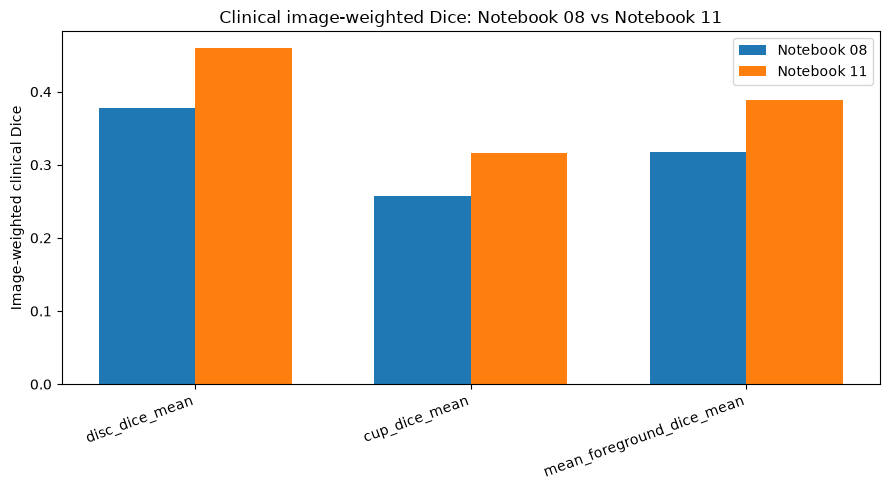

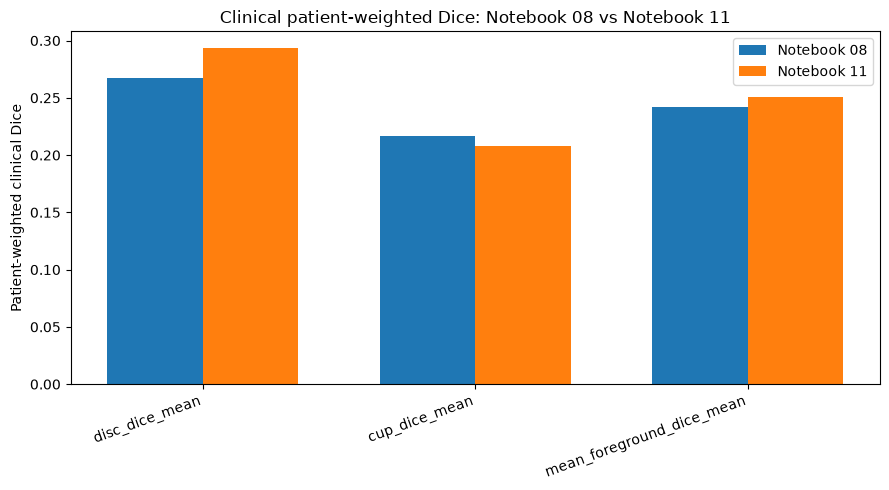

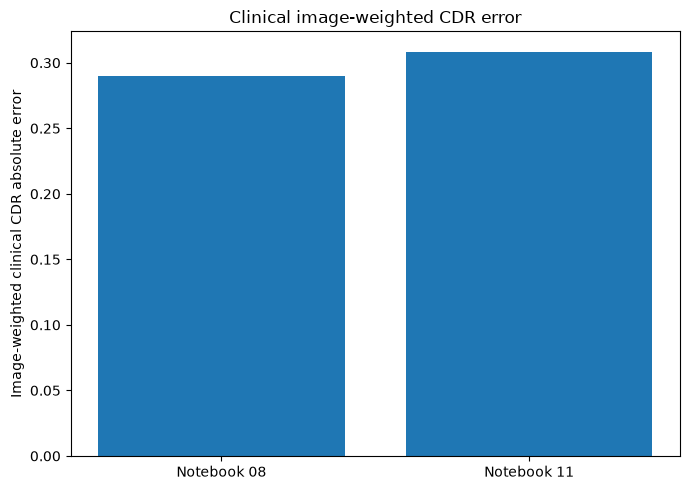

,metric,higher_is_better,notebook08_image_weighted,notebook11_image_weighted,image_weighted_delta_notebook11_minus_notebook08,image_weighted_improvement_directional,image_weighted_improved,notebook08_patient_weighted,notebook11_patient_weighted,patient_weighted_delta_notebook11_minus_notebook08,patient_weighted_improvement_directional,patient_weighted_improved
0,disc_dice_mean,True,0.377686,0.459569,0.081883,0.081883,True,0.267402,0.293403,0.026002,0.026002,True
1,cup_dice_mean,True,0.257740,0.316686,0.058946,0.058946,True,0.216632,0.208354,-0.008277,-0.008277,False
2,mean_foreground_dice_mean,True,0.317713,0.388127,0.070415,0.070415,True,0.242017,0.250879,0.008862,0.008862,True
3,cdr_abs_error_mean,False,0.290072,0.308559,0.018487,-0.018487,False,0.283353,0.383213,0.099861,-0.099861,False


In [12]:
# 11.12 — Clinical generalization comparison visualization

comparison = pd.read_csv(COMPARISON_PATH)

dice_plot = comparison.loc[
    comparison["metric"].isin(
        ["disc_dice_mean", "cup_dice_mean", "mean_foreground_dice_mean"]
    )
].copy()

x = np.arange(len(dice_plot))
width = 0.35

plt.figure(figsize=(9, 5))
plt.bar(x - width / 2, dice_plot["notebook08_image_weighted"], width, label="Notebook 08")
plt.bar(x + width / 2, dice_plot["notebook11_image_weighted"], width, label="Notebook 11")
plt.xticks(x, dice_plot["metric"], rotation=20, ha="right")
plt.ylabel("Image-weighted clinical Dice")
plt.title("Clinical image-weighted Dice: Notebook 08 vs Notebook 11")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 5))
plt.bar(x - width / 2, dice_plot["notebook08_patient_weighted"], width, label="Notebook 08")
plt.bar(x + width / 2, dice_plot["notebook11_patient_weighted"], width, label="Notebook 11")
plt.xticks(x, dice_plot["metric"], rotation=20, ha="right")
plt.ylabel("Patient-weighted clinical Dice")
plt.title("Clinical patient-weighted Dice: Notebook 08 vs Notebook 11")
plt.legend()
plt.tight_layout()
plt.show()

cdr_plot = comparison.loc[comparison["metric"] == "cdr_abs_error_mean"].copy()

plt.figure(figsize=(7, 5))
plt.bar(["Notebook 08", "Notebook 11"], [
    float(cdr_plot["notebook08_image_weighted"].iloc[0]),
    float(cdr_plot["notebook11_image_weighted"].iloc[0]),
])
plt.ylabel("Image-weighted clinical CDR absolute error")
plt.title("Clinical image-weighted CDR error")
plt.tight_layout()
plt.show()

display(comparison)


In [13]:
# 11.13 — Final handoff summary

comparison = pd.read_csv(COMPARISON_PATH)
metadata = pd.read_csv(METADATA_PATH).iloc[0].to_dict()
image_summary = pd.read_csv(IMAGE_WEIGHTED_SUMMARY_PATH).iloc[0].to_dict()
patient_summary = pd.read_csv(PATIENT_WEIGHTED_SUMMARY_PATH).iloc[0].to_dict()

mean_dice_row = comparison.loc[comparison["metric"] == "mean_foreground_dice_mean"].iloc[0]
cdr_row = comparison.loc[comparison["metric"] == "cdr_abs_error_mean"].iloc[0]

handoff = {
    "notebook": "11_long_training_clinical_generalization",
    "source_model_notebook": "10_long_training_selected_public_model",
    "clinical_data_usage": "evaluation_only",
    "model_strategy": metadata["strategy_name"],
    "component_strategies": metadata["component_strategies"],
    "checkpoint_epoch": metadata["checkpoint_epoch"],
    "public_test_mean_foreground_dice": metadata["public_test_mean_foreground_dice"],
    "clinical_image_weighted_mean_foreground_dice": image_summary.get("image_weighted_mean_foreground_dice_mean", np.nan),
    "clinical_patient_weighted_mean_foreground_dice": patient_summary.get("patient_weighted_mean_foreground_dice_mean", np.nan),
    "image_weighted_mean_dice_delta_vs_notebook_08": mean_dice_row[
        "image_weighted_delta_notebook11_minus_notebook08"
    ],
    "patient_weighted_mean_dice_delta_vs_notebook_08": mean_dice_row[
        "patient_weighted_delta_notebook11_minus_notebook08"
    ],
    "clinical_image_weighted_cdr_abs_error": image_summary.get("image_weighted_cdr_abs_error_mean", np.nan),
    "clinical_patient_weighted_cdr_abs_error": patient_summary.get("patient_weighted_cdr_abs_error_mean", np.nan),
    "image_weighted_cdr_error_improvement_vs_notebook_08": cdr_row[
        "image_weighted_improvement_directional"
    ],
    "patient_weighted_cdr_error_improvement_vs_notebook_08": cdr_row[
        "patient_weighted_improvement_directional"
    ],
    "next_notebook": "12_clinical_domain_adaptation_experiments.ipynb",
    "next_step": (
        "Test whether adding controlled fractions of clinical-domain data to training "
        "improves held-out clinical performance. These experiments are clinical-domain "
        "adaptation, not pure generalization."
    ),
}

display(pd.DataFrame([handoff]).T.rename(columns={0: "value"}))


,value
notebook,11_long_training_clinical_generalization
source_model_notebook,10_long_training_selected_public_model
clinical_data_usage,evaluation_only
model_strategy,combo_affine_vignette_blur
component_strategies,small_affine;vignette_illumination;defocus_blur
checkpoint_epoch,24
public_test_mean_foreground_dice,0.842136
clinical_image_weighted_mean_foreground_dice,0.388127
clinical_patient_weighted_mean_foreground_dice,0.250879
image_weighted_mean_dice_delta_vs_notebook_08,0.070415
